In [6]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelite imports: we load the following interfaces
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
#from cloelib.cosmology.class_cosmology import CLASSBackground, CLASSLinearPerturbations, CLASSNonLinearPerturbations
from cloelib.cosmology.jax_cosmology import JAXBackground

# Validation benchmark in astropy
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import camb

In [ ]:
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
omch2 = 0.12
Omega_cdm0 = omch2/h**2
ombh2 = 0.022
Omega_b0 = ombh2/h**2
Omega_k0 = 0.
w = -1.
wa = 0.
ns = 0.96
mnu = 0.
As=2e-9

# Astropy
Tcmb = 2.7255
Neff = 0.0#3.046
YHe = 0.2454

# z-array
z = np.linspace(0, 3, 100)

#astropy_instance = FlatLambdaCDM(H0=H0,Om0=Omm,Ob0=Omb,Tcmb0=Tcmb,Neff=Neff,m_nu=[0,0,0.0]*u.eV)
#H_z_astropy = astropy_instance.H(z).to(u.km/u.s/u.Mpc).value

camb_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=0., w0=-1.0, wa=0.0, 
                               gamma_MG=0.0)
H_z_camb = camb_instance.hubble_parameter(z, units='km/s/Mpc')
chi_z_camb = camb_instance.comoving_distance(z)

class_instance = CLASSBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=0., w0=-1.0, wa=0.0, 
                               gamma_MG=0.0)
H_z_class = class_instance.hubble_parameter(z)
chi_z_class = class_instance.comoving_distance(z)

#jax_instance = JAXBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, sigma8=sigma8, Omk = 0.0, ns = 0.96, As = 2e-9, gamma_MG = 0.545)
#H_z_jax = jax_instance.hubble_parameter(z)

#plt.figure(figsize = (18,8))
plt.plot(z, H_z_camb, label = 'CAMB', ls='--')
plt.plot(z, H_z_class, label = 'CLASS')
#plt.plot(z, 100*(H_z_jax- H_z_astropy)/H_z_astropy, label = 'Astropy vs. JAX')
plt.ylabel('H(z)')
#plt.title('Percentage Difference in H(z) between Astropy and CAMB')
plt.xlabel('Redshift z')
plt.legend()

#Differences are due to neutrinos

NameError: name 'CLASSBackground' is not defined

In [3]:
zs = z
ks = np.logspace(np.log10(1e-4), np.log10(5), 100)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


Text(0.5, 1.0, 'CAMB Perturbations')

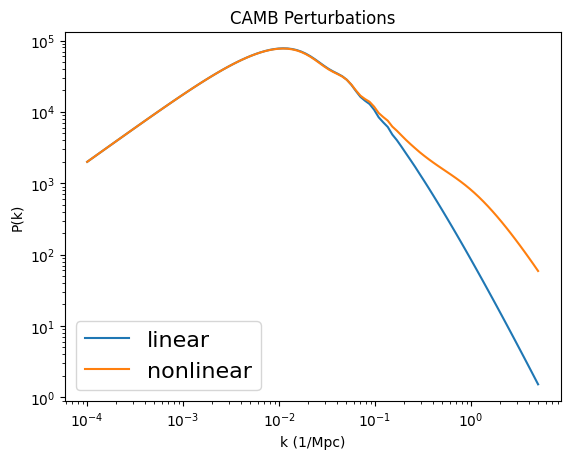

In [5]:
# CAMB PERTURBATIONS
camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance, redshifts=z, 
                                            nonlinear_model='mead2016')

linear_pk_camb = camb_linear.matter_power_spectrum(zs, ks)
nonlinear_pk_camb = camb_nonlinear.matter_power_spectrum(zs, ks)
plt.loglog(ks, linear_pk_camb[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_camb[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)')
plt.ylabel('P(k)')
plt.legend(fontsize = 16)
plt.title("CAMB Perturbations")

In [6]:
## Print array shapes
print(camb_linear.z.shape)
print(camb_linear.k.shape)
print(linear_pk_camb.shape)
print(min(camb_linear.z), max(camb_linear.z))

(100,)
(227,)
(100, 100)
0.0 3.0


Text(0.5, 1.0, 'CLASS Perturbations')

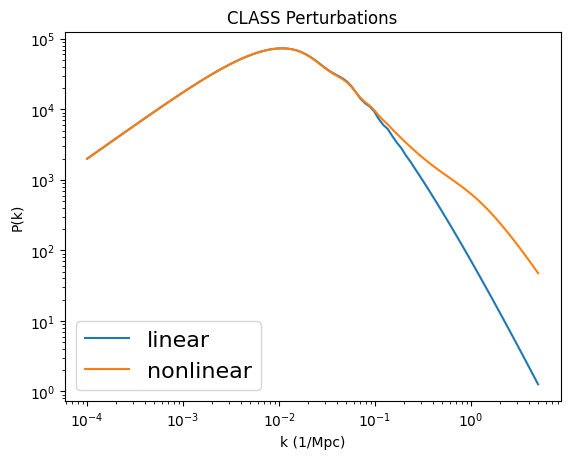

In [7]:
# CLASS PERTURBATIONS
# k-array
class_linear = CLASSLinearPerturbations(background=class_instance, redshifts=z)
class_nonlinear = CLASSNonLinearPerturbations(background=class_instance, 
                                              redshifts=z, 
                                              nonlinear_model='hmcode')
linear_pk_class = class_linear.matter_power_spectrum(zs, ks)
nonlinear_pk_class = class_nonlinear.matter_power_spectrum(zs, ks)
plt.loglog(ks, linear_pk_class[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_class[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)')
plt.ylabel('P(k)')
plt.legend(fontsize = 16)
plt.title("CLASS Perturbations")

In [8]:
## Print array shapes
print(class_linear.z.shape)
print(linear_pk_class.shape)
print(min(class_linear.z), max(class_linear.z))

(100,)
(100, 100)
0.0 3.0


Text(0.5, 1.0, 'CLASS vs. CAMB NonLinearPerturbations')

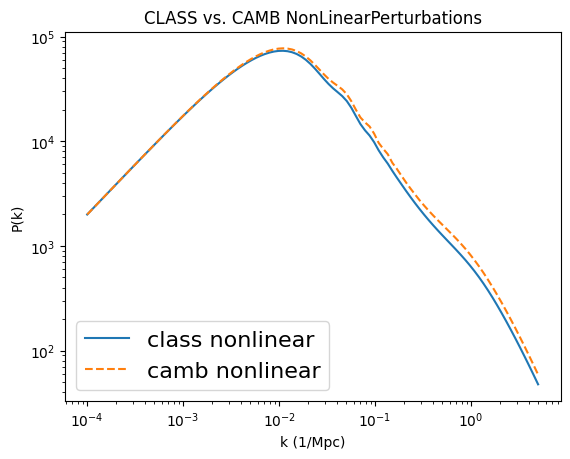

In [10]:
plt.loglog(ks, nonlinear_pk_class[0, :], label= 'class nonlinear')
plt.loglog(ks, nonlinear_pk_camb[0, :], ls='--', label= 'camb nonlinear')
plt.xlabel('k (1/Mpc)')
plt.ylabel('P(k)')
plt.legend(fontsize = 16)
plt.title("CLASS vs. CAMB NonLinearPerturbations")

Text(0.5, 1.0, 'CLASS vs. CAMB LinearPerturbations')

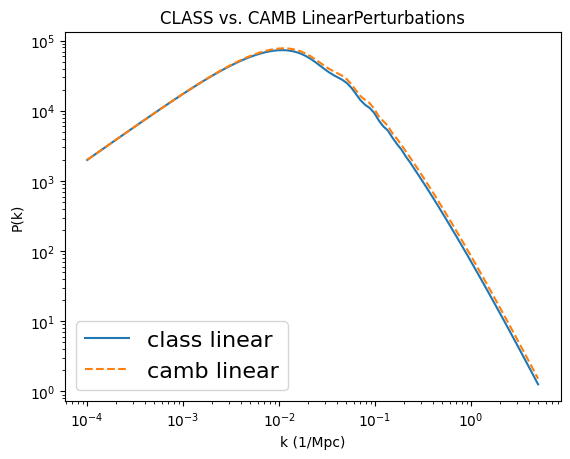

In [11]:
plt.loglog(ks, linear_pk_class[0, :], label= 'class linear')
plt.loglog(ks, linear_pk_camb[0, :], ls='--', label= 'camb linear')
plt.xlabel('k (1/Mpc)')
plt.ylabel('P(k)')
plt.legend(fontsize = 16)
plt.title("CLASS vs. CAMB LinearPerturbations")

Text(0.5, 1.0, 'CAMB Linear Perturbations')

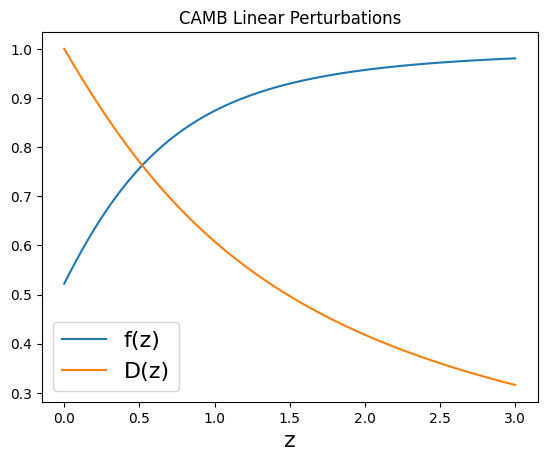

In [12]:
#calculate results for these parameters
plt.plot(z, camb_linear.growth_rate(), label = 'f(z)')
plt.plot(z, camb_linear.growth_factor(zs,ks)[:, 0], label = 'D(z)')
plt.xlabel('z', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CAMB Linear Perturbations")

Text(0.5, 1.0, 'CLASS Linear Perturbations')

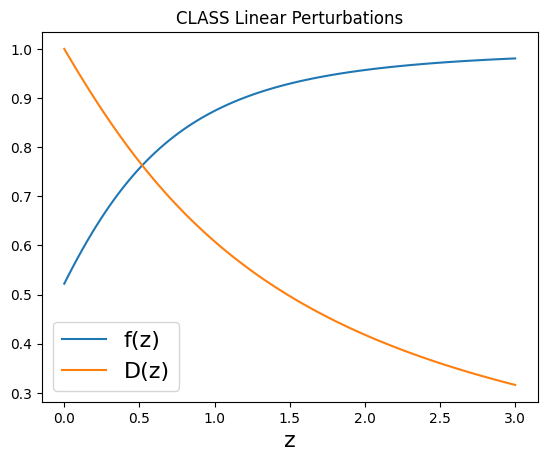

In [13]:
#calculate results for these parameters
plt.plot(zs, class_linear.growth_rate(), label = 'f(z)')
plt.plot(zs, class_linear.growth_factor(zs,ks)[:, 0], label = 'D(z)')
plt.xlabel('z', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CLASS Linear Perturbations")